# AI Chip Stocks Analysis

**Stocks:** NVDA (NVIDIA), AMD (Advanced Micro Devices), TSM (TSMC)  
**Period:** 2 years of daily historical data  
**Sections:**
1. Data Collection
2. Price History
3. Returns Analysis
4. Volatility Analysis
5. Moving Averages (50-day & 200-day)
6. Correlation Heatmap
7. Volume Analysis
8. Summary Statistics

---

## Section 1 — Data Collection

We use `yfinance` to pull 2 years of daily OHLCV data for NVDA, AMD, and TSM (TSMC's NYSE ADR ticker).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta

# ── Style ────────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

CHARTS_DIR = Path('charts')
CHARTS_DIR.mkdir(exist_ok=True)

# ── Parameters ───────────────────────────────────────────────────────────────
TICKERS   = ['NVDA', 'AMD', 'TSM']
COLORS    = {'NVDA': '#76b900', 'AMD': '#ed1c24', 'TSM': '#005bac'}
PERIOD    = '2y'
TODAY     = datetime.today().strftime('%Y-%m-%d')

print(f'Fetching data for {TICKERS}  —  period: {PERIOD}  (as of {TODAY})')

Fetching data for ['NVDA', 'AMD', 'TSM']  —  period: 2y  (as of 2026-05-24)


In [2]:
# Download OHLCV data
raw = yf.download(TICKERS, period=PERIOD, auto_adjust=True, progress=False)

close  = raw['Close'].dropna()
volume = raw['Volume'].dropna()
high   = raw['High'].dropna()
low    = raw['Low'].dropna()
open_  = raw['Open'].dropna()

print(f'\nDate range : {close.index[0].date()}  →  {close.index[-1].date()}')
print(f'Trading days: {len(close)}')
print('\nClosing price — last 5 rows:')
close.tail()


Date range : 2024-05-23  →  2026-05-22
Trading days: 501

Closing price — last 5 rows:


Ticker,AMD,NVDA,TSM
2026-05-18,420.989990,222.320007,395.950012
2026-05-19,414.049988,220.610001,392.609985
2026-05-20,447.579987,223.470001,401.619995
2026-05-21,449.589996,219.509995,407.149994
2026-05-22,467.510010,215.330002,404.519989


## Section 2 — Price History

Adjusted closing prices over the full 2-year window, one panel per stock.

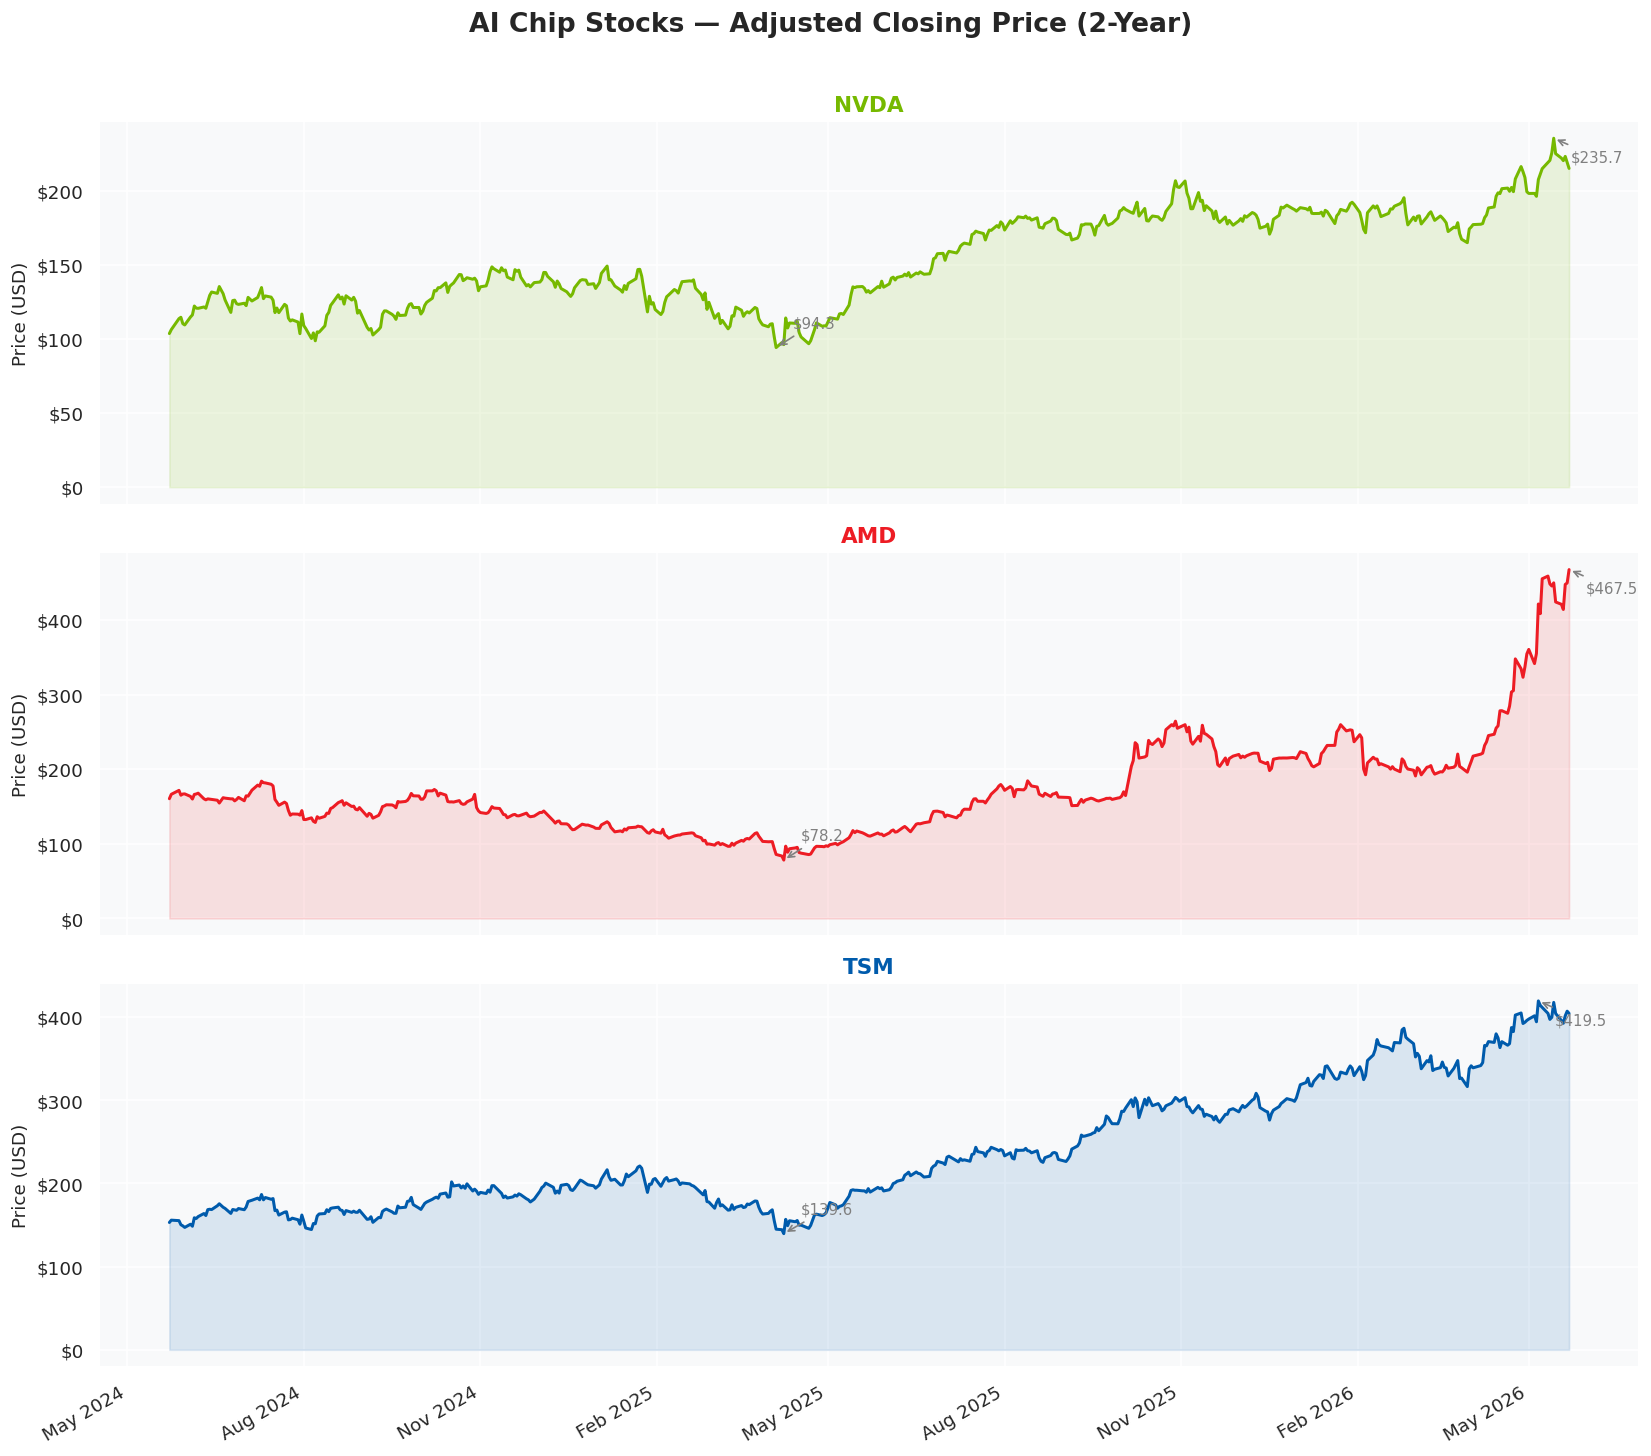

Saved → charts/01_price_history.png


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('AI Chip Stocks — Adjusted Closing Price (2-Year)', fontsize=16, fontweight='bold', y=1.01)

for ax, ticker in zip(axes, TICKERS):
    color = COLORS[ticker]
    ax.plot(close.index, close[ticker], color=color, linewidth=1.8, label=ticker)
    ax.fill_between(close.index, close[ticker], alpha=0.12, color=color)

    # Annotate min / max
    ymin_idx = close[ticker].idxmin()
    ymax_idx = close[ticker].idxmax()
    ax.annotate(f'${close[ticker][ymin_idx]:.1f}',
                xy=(ymin_idx, close[ticker][ymin_idx]),
                xytext=(10, 12), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
    ax.annotate(f'${close[ticker][ymax_idx]:.1f}',
                xy=(ymax_idx, close[ticker][ymax_idx]),
                xytext=(10, -14), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

    ax.set_ylabel('Price (USD)', fontsize=11)
    ax.set_title(f'{ticker}', fontsize=13, color=color, fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
fig.savefig(CHARTS_DIR / '01_price_history.png', bbox_inches='tight')
plt.show()
print('Saved → charts/01_price_history.png')

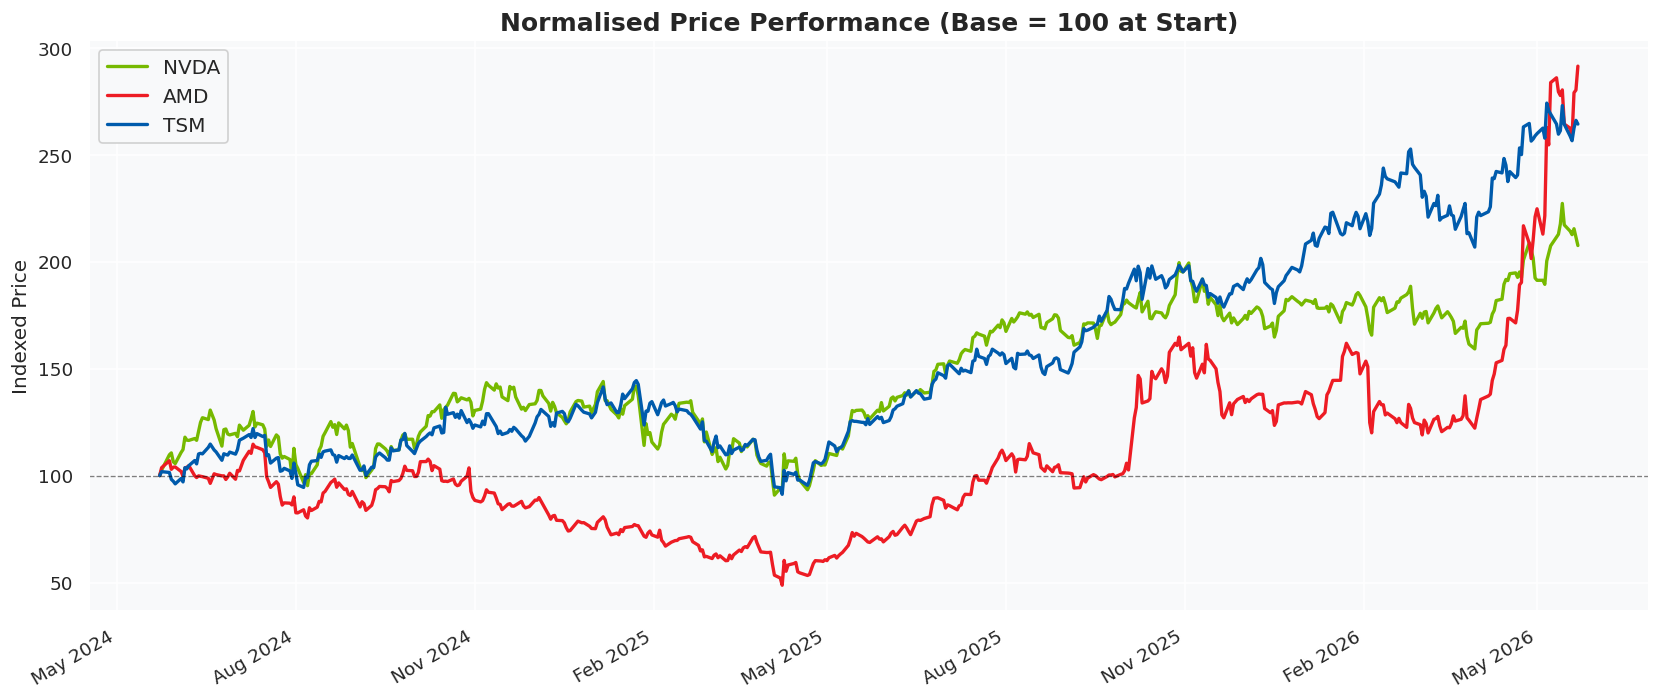

Saved → charts/02_normalised_price.png


In [4]:
# Normalised price (rebased to 100 on day 0) — all three on one chart
rebased = (close / close.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    ax.plot(rebased.index, rebased[ticker], color=COLORS[ticker],
            linewidth=2, label=ticker)

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Normalised Price Performance (Base = 100 at Start)', fontsize=15, fontweight='bold')
ax.set_ylabel('Indexed Price', fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=12, framealpha=0.9)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '02_normalised_price.png', bbox_inches='tight')
plt.show()
print('Saved → charts/02_normalised_price.png')

## Section 3 — Returns Analysis

Daily log-returns, cumulative returns, and a distribution comparison.

In [5]:
daily_returns = close.pct_change().dropna()
log_returns   = np.log(close / close.shift(1)).dropna()
cum_returns   = (1 + daily_returns).cumprod() - 1

print('=== Daily Return Summary ===')
summary = daily_returns.describe().T
summary.index.name = 'Ticker'
summary['total_return'] = cum_returns.iloc[-1]
summary['annualised_return'] = ((1 + summary['total_return']) ** (252 / len(daily_returns)) - 1)
print(summary[['mean','std','min','max','total_return','annualised_return']].to_string())

=== Daily Return Summary ===
            mean       std       min       max  total_return  annualised_return
Ticker                                                                         
AMD     0.002824  0.037410 -0.173144  0.238205      1.914106           0.714394
NVDA    0.001924  0.030406 -0.169682  0.187227      1.075661           0.444930
TSM     0.002285  0.026059 -0.133270  0.122940      1.643450           0.632203


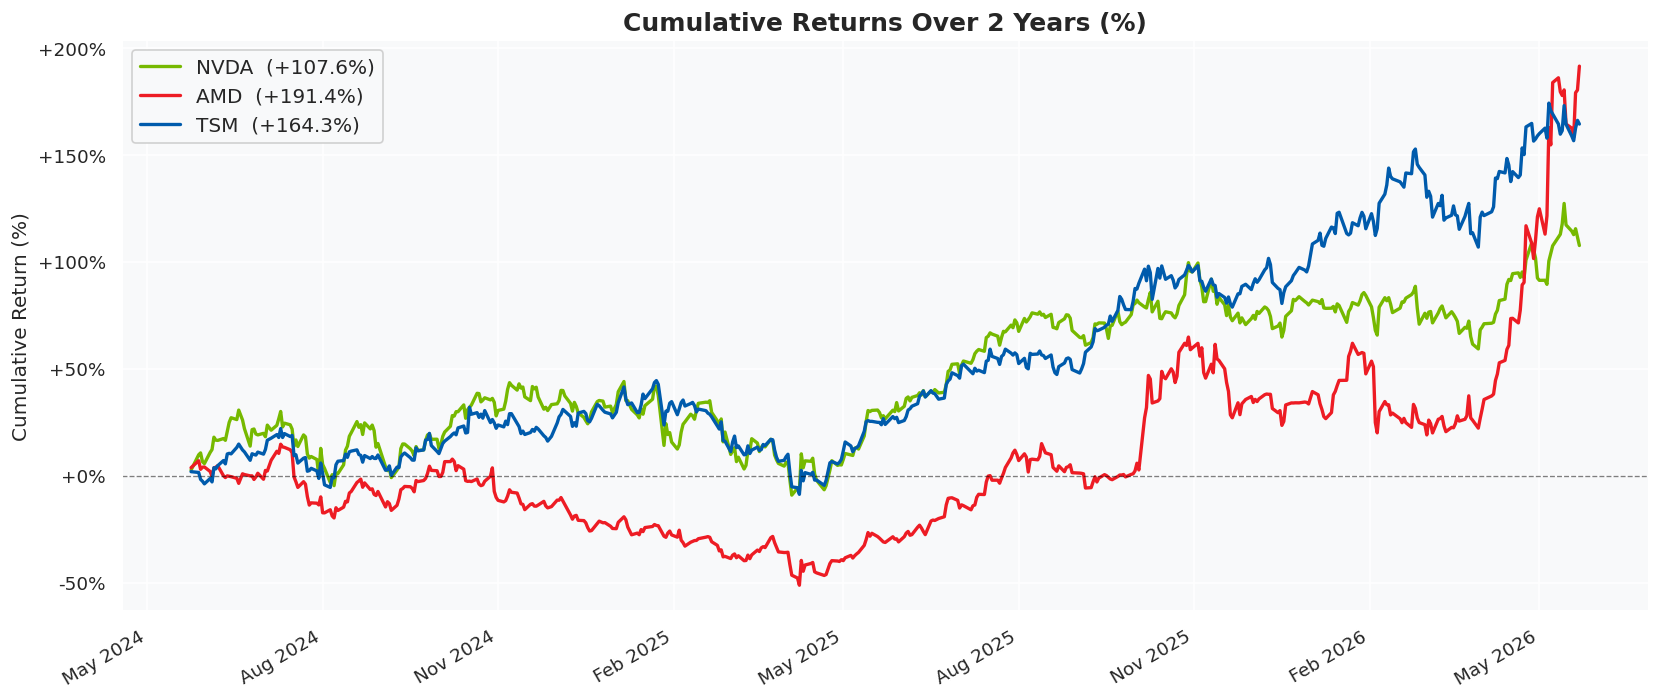

Saved → charts/03_cumulative_returns.png


In [6]:
# Cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    final = cum_returns[ticker].iloc[-1] * 100
    ax.plot(cum_returns.index, cum_returns[ticker] * 100,
            color=COLORS[ticker], linewidth=2,
            label=f'{ticker}  ({final:+.1f}%)')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Cumulative Returns Over 2 Years (%)', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=12, framealpha=0.9)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '03_cumulative_returns.png', bbox_inches='tight')
plt.show()
print('Saved → charts/03_cumulative_returns.png')

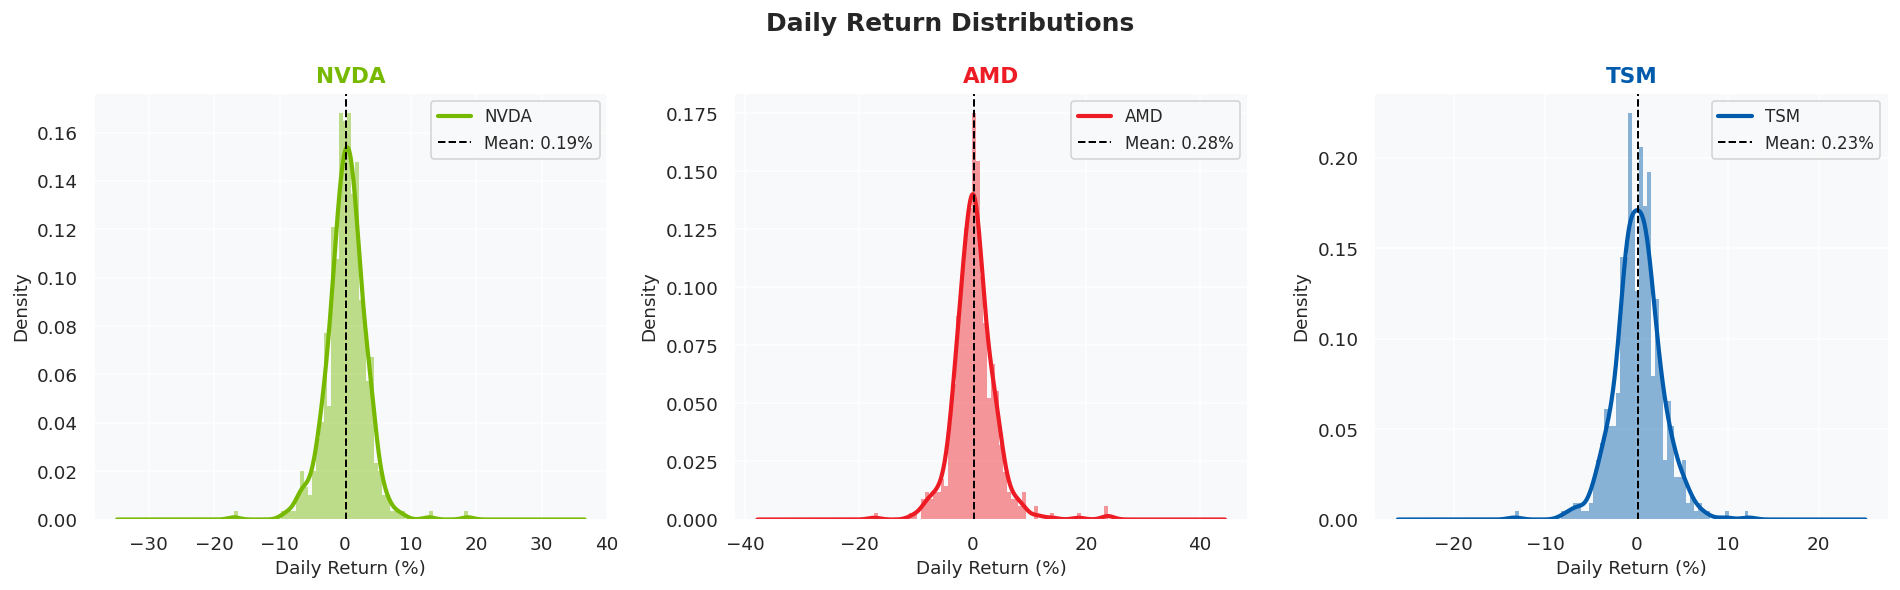

Saved → charts/04_return_distributions.png


In [7]:
# Return distributions (KDE + histogram)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Daily Return Distributions', fontsize=15, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    data = daily_returns[ticker] * 100
    color = COLORS[ticker]
    ax.hist(data, bins=60, color=color, alpha=0.45, density=True, edgecolor='none')
    data.plot.kde(ax=ax, color=color, linewidth=2.5)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: {data.mean():.2f}%')
    ax.set_title(ticker, fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Daily Return (%)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '04_return_distributions.png', bbox_inches='tight')
plt.show()
print('Saved → charts/04_return_distributions.png')

## Section 4 — Volatility Analysis

Rolling 30-day annualised volatility and a comparative bar chart of overall risk metrics.

In [8]:
WINDOW = 30  # trading days
roll_vol = daily_returns.rolling(WINDOW).std() * np.sqrt(252) * 100  # annualised %

print(f'=== {WINDOW}-Day Rolling Annualised Volatility (latest) ===')
for ticker in TICKERS:
    print(f'  {ticker}: {roll_vol[ticker].iloc[-1]:.1f}%')

=== 30-Day Rolling Annualised Volatility (latest) ===
  NVDA: 39.4%
  AMD: 88.1%
  TSM: 40.0%


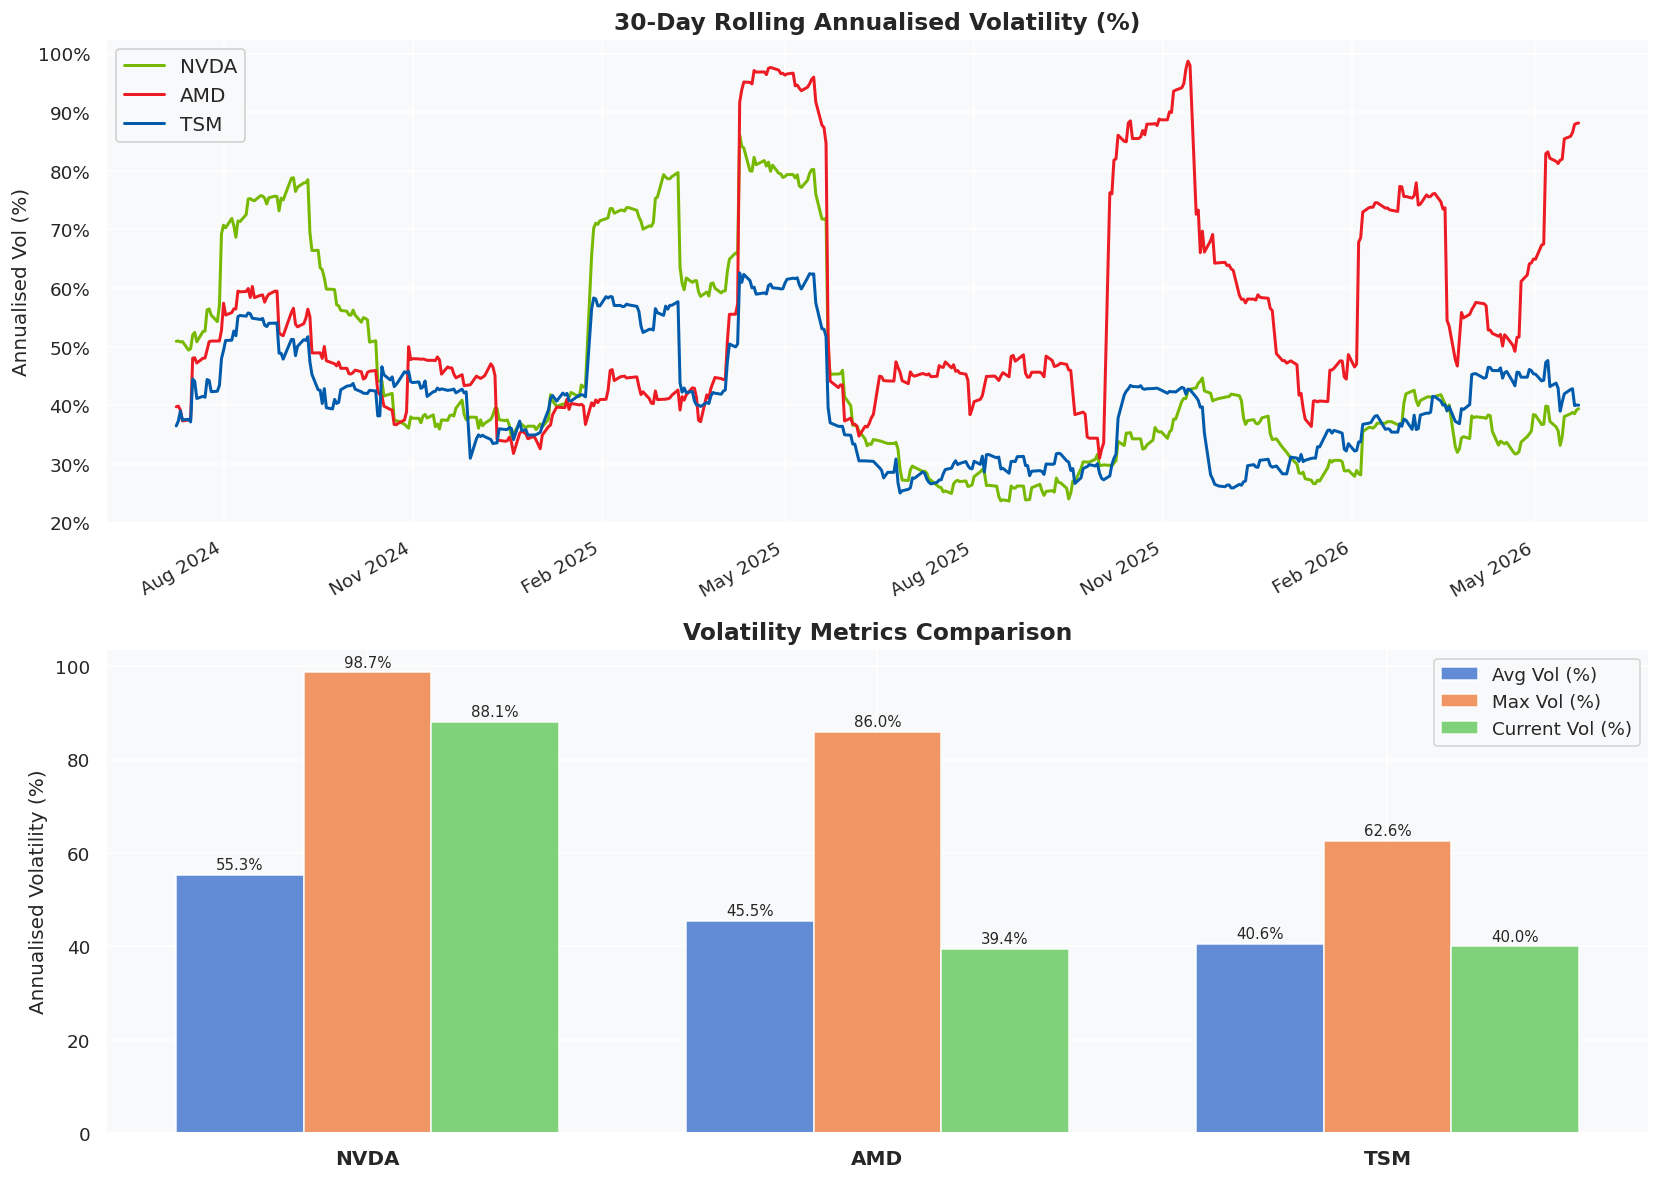

Saved → charts/05_volatility.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Panel 1 — rolling volatility time series
ax = axes[0]
for ticker in TICKERS:
    ax.plot(roll_vol.index, roll_vol[ticker],
            color=COLORS[ticker], linewidth=1.8, label=ticker)
ax.set_title(f'{WINDOW}-Day Rolling Annualised Volatility (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Annualised Vol (%)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=12, framealpha=0.9)

# Panel 2 — overall vol metrics bar chart
ax2 = axes[1]
vol_metrics = pd.DataFrame({
    'Avg Vol (%)':   roll_vol.mean(),
    'Max Vol (%)':   roll_vol.max(),
    'Current Vol (%)': roll_vol.iloc[-1],
})
x = np.arange(len(TICKERS))
width = 0.25
for i, col in enumerate(vol_metrics.columns):
    bars = ax2.bar(x + i * width, vol_metrics[col], width,
                   label=col, alpha=0.85)
    for bar, val in zip(bars, vol_metrics[col]):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x + width)
ax2.set_xticklabels(TICKERS, fontsize=12, fontweight='bold')
ax2.set_title('Volatility Metrics Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Annualised Volatility (%)', fontsize=12)
ax2.legend(fontsize=11)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '05_volatility.png', bbox_inches='tight')
plt.show()
print('Saved → charts/05_volatility.png')

## Section 5 — Moving Averages (50-day & 200-day)

The 50-day and 200-day SMAs are classic momentum / trend indicators.  
A **Golden Cross** (MA50 crosses above MA200) is bullish; a **Death Cross** is bearish.

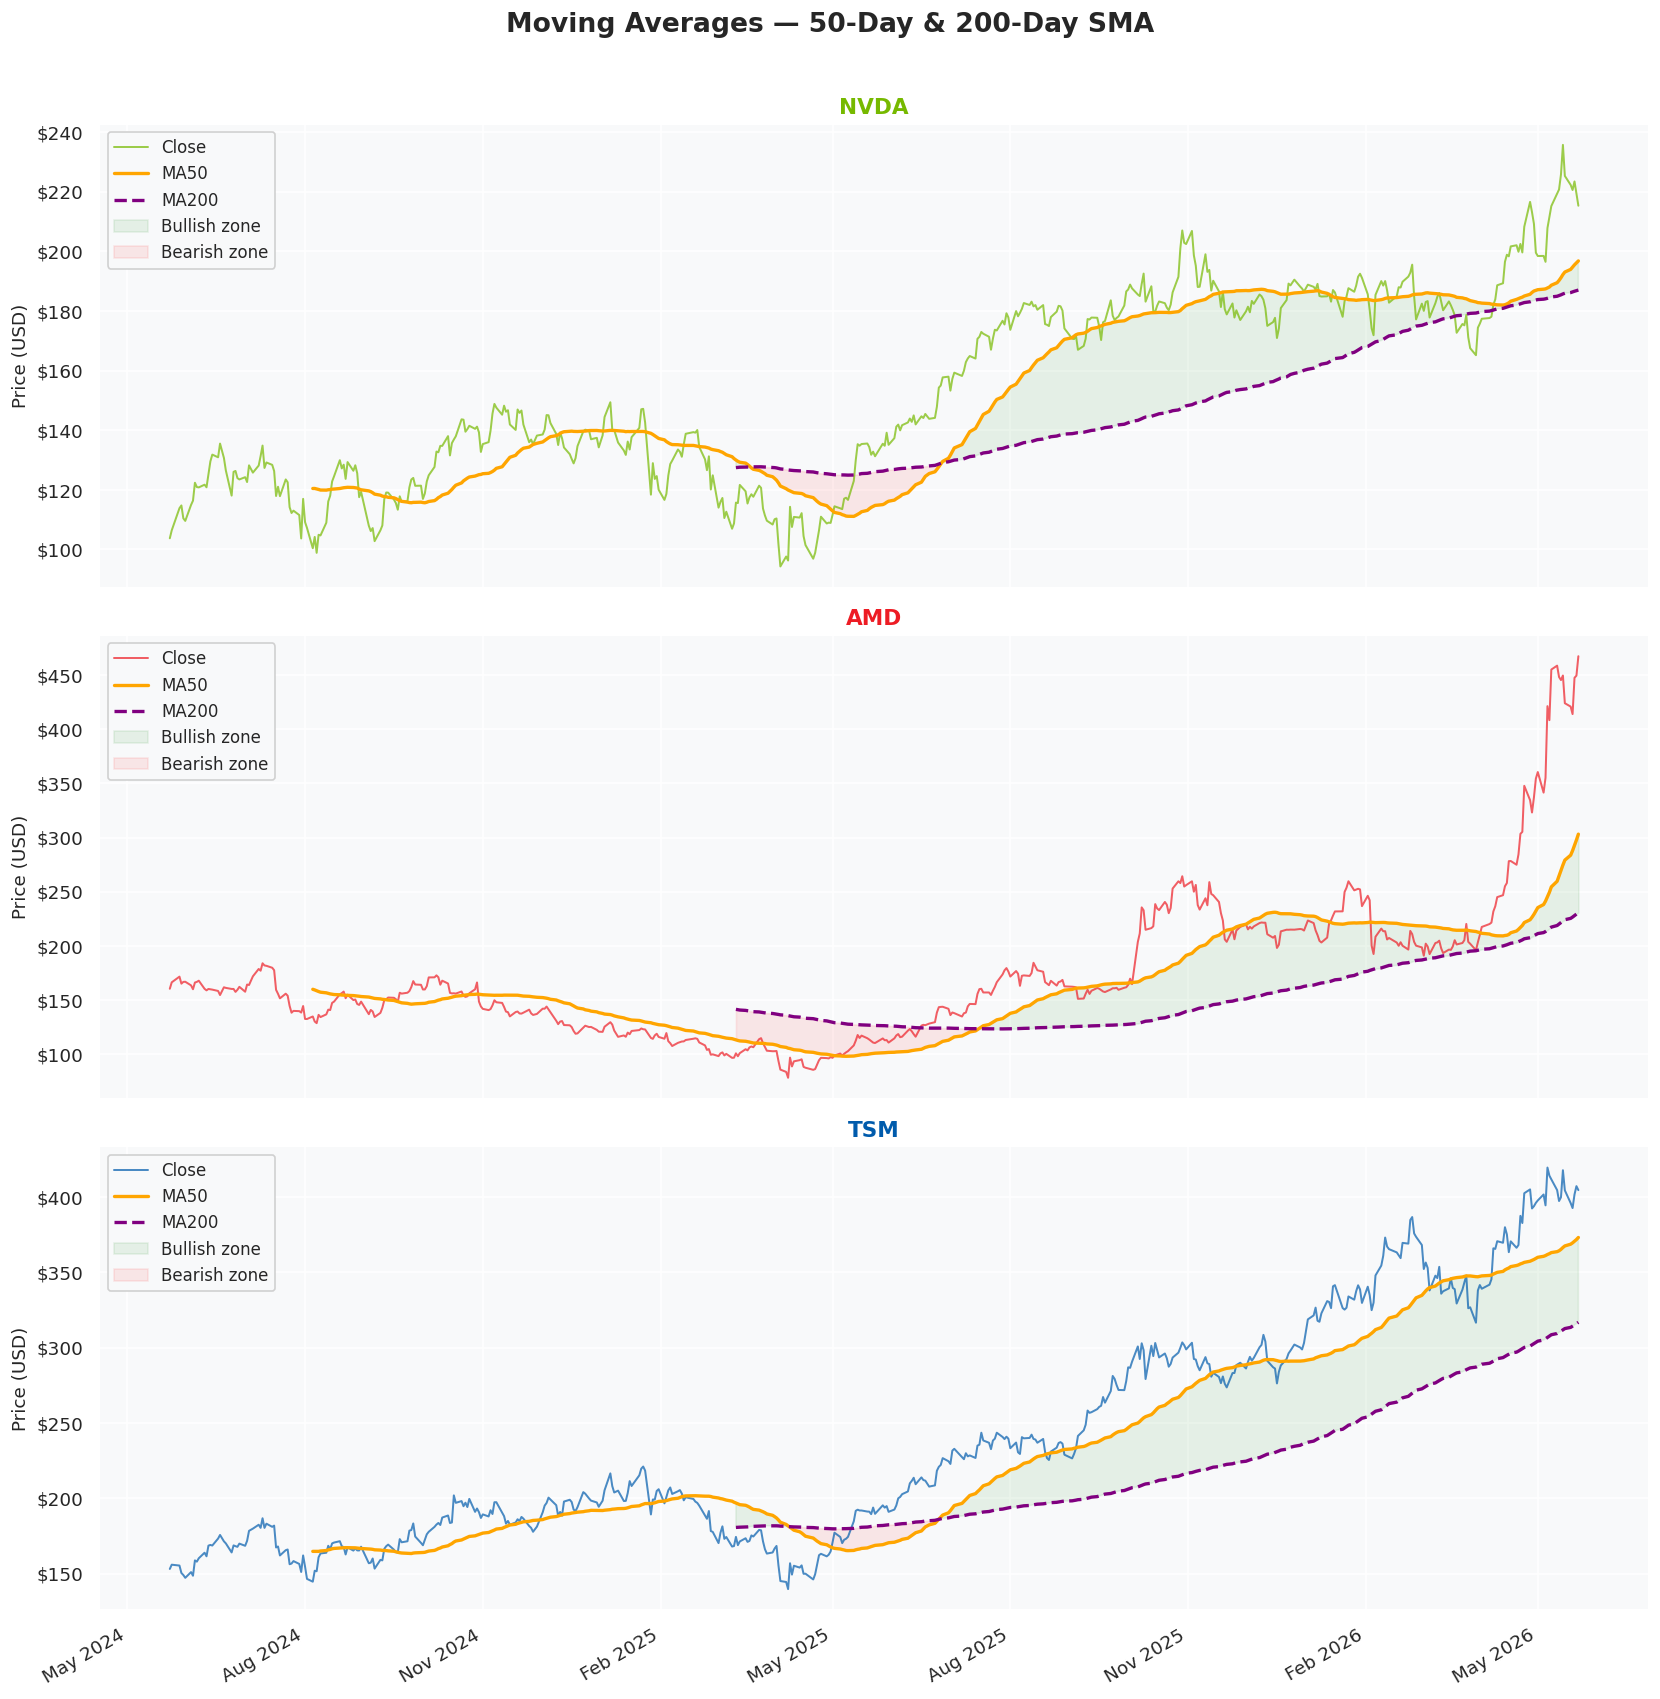

Saved → charts/06_moving_averages.png


In [10]:
ma50  = close.rolling(50).mean()
ma200 = close.rolling(200).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Moving Averages — 50-Day & 200-Day SMA', fontsize=16, fontweight='bold', y=1.01)

for ax, ticker in zip(axes, TICKERS):
    color = COLORS[ticker]
    ax.plot(close.index,  close[ticker],  color=color, linewidth=1.2, alpha=0.7,  label='Close')
    ax.plot(ma50.index,   ma50[ticker],   color='orange',  linewidth=2,   linestyle='-',  label='MA50')
    ax.plot(ma200.index,  ma200[ticker],  color='purple',  linewidth=2,   linestyle='--', label='MA200')

    # Shade golden-cross & death-cross regions
    diff = ma50[ticker] - ma200[ticker]
    above = diff > 0
    ax.fill_between(close.index, ma50[ticker], ma200[ticker],
                    where=above,  alpha=0.08, color='green',  label='Bullish zone')
    ax.fill_between(close.index, ma50[ticker], ma200[ticker],
                    where=~above, alpha=0.08, color='red',    label='Bearish zone')

    ax.set_title(ticker, fontsize=13, color=color, fontweight='bold')
    ax.set_ylabel('Price (USD)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=10, loc='upper left', framealpha=0.9)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '06_moving_averages.png', bbox_inches='tight')
plt.show()
print('Saved → charts/06_moving_averages.png')

## Section 6 — Correlation Heatmap

How closely do these three stocks move together?  
We examine both price-level correlation and daily-returns correlation.

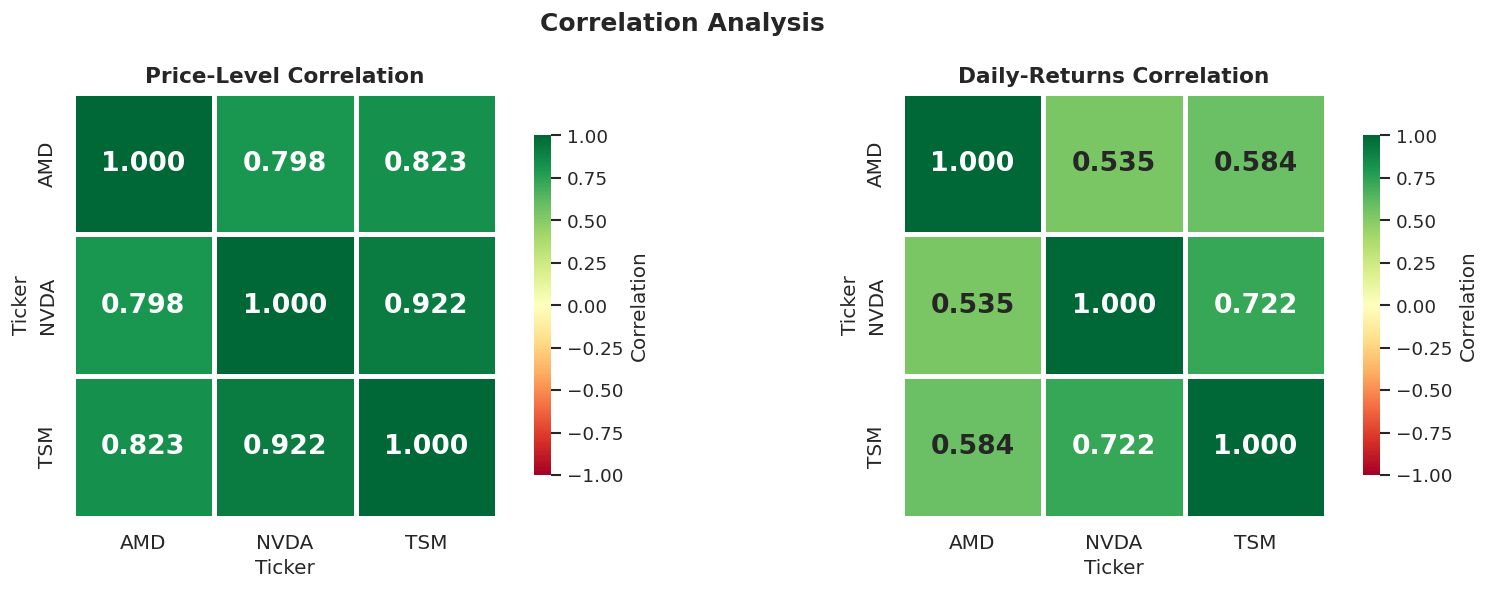

Saved → charts/07_correlation_heatmap.png


In [11]:
price_corr   = close.corr()
returns_corr = daily_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlation Analysis', fontsize=15, fontweight='bold')

annot_kws = {'size': 16, 'weight': 'bold'}

for ax, corr_mat, title in zip(
    axes,
    [price_corr, returns_corr],
    ['Price-Level Correlation', 'Daily-Returns Correlation']):

    mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)  # upper triangle
    sns.heatmap(
        corr_mat, annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=-1, vmax=1, ax=ax,
        linewidths=2, linecolor='white',
        annot_kws=annot_kws,
        square=True,
        cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '07_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved → charts/07_correlation_heatmap.png')

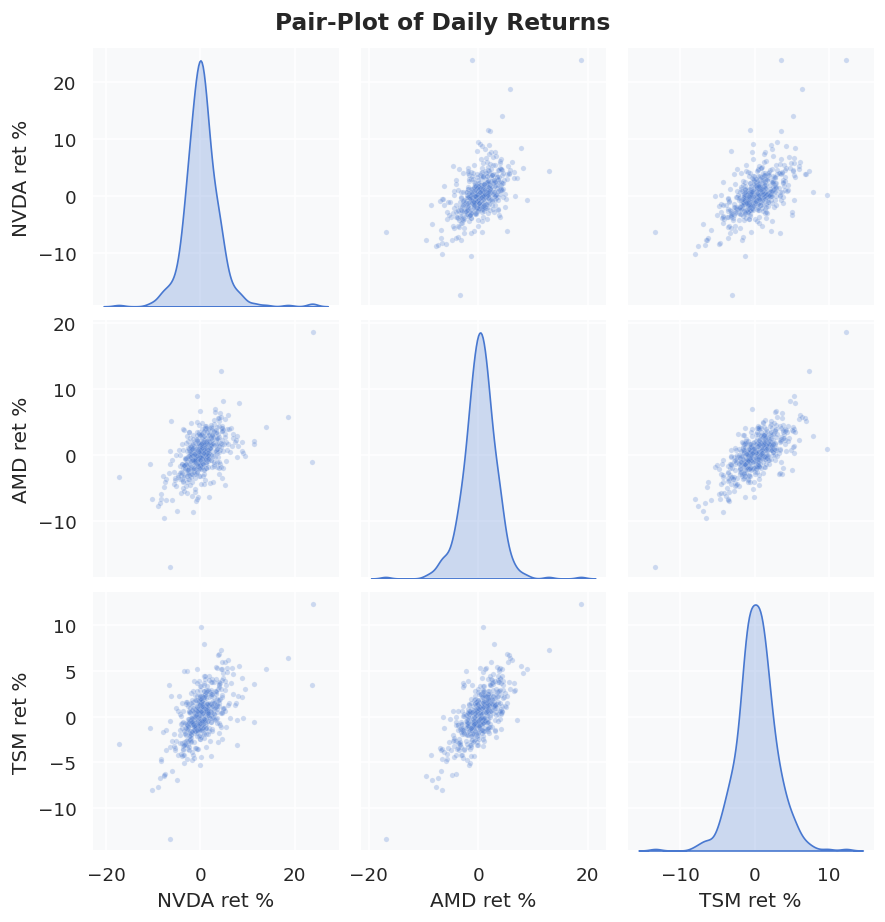

Saved → charts/08_returns_pairplot.png


In [12]:
# Pair-scatter matrix of daily returns
pairs_df = daily_returns.copy() * 100
pairs_df.columns = [f'{t} ret %' for t in TICKERS]

pg = sns.pairplot(pairs_df, diag_kind='kde', plot_kws={'alpha': 0.25, 's': 10},
                  diag_kws={'fill': True})
pg.figure.suptitle('Pair-Plot of Daily Returns', y=1.02, fontsize=14, fontweight='bold')

pg.figure.savefig(CHARTS_DIR / '08_returns_pairplot.png', bbox_inches='tight')
plt.show()
print('Saved → charts/08_returns_pairplot.png')

## Section 7 — Volume Analysis

Trading volume reveals market conviction behind price moves.

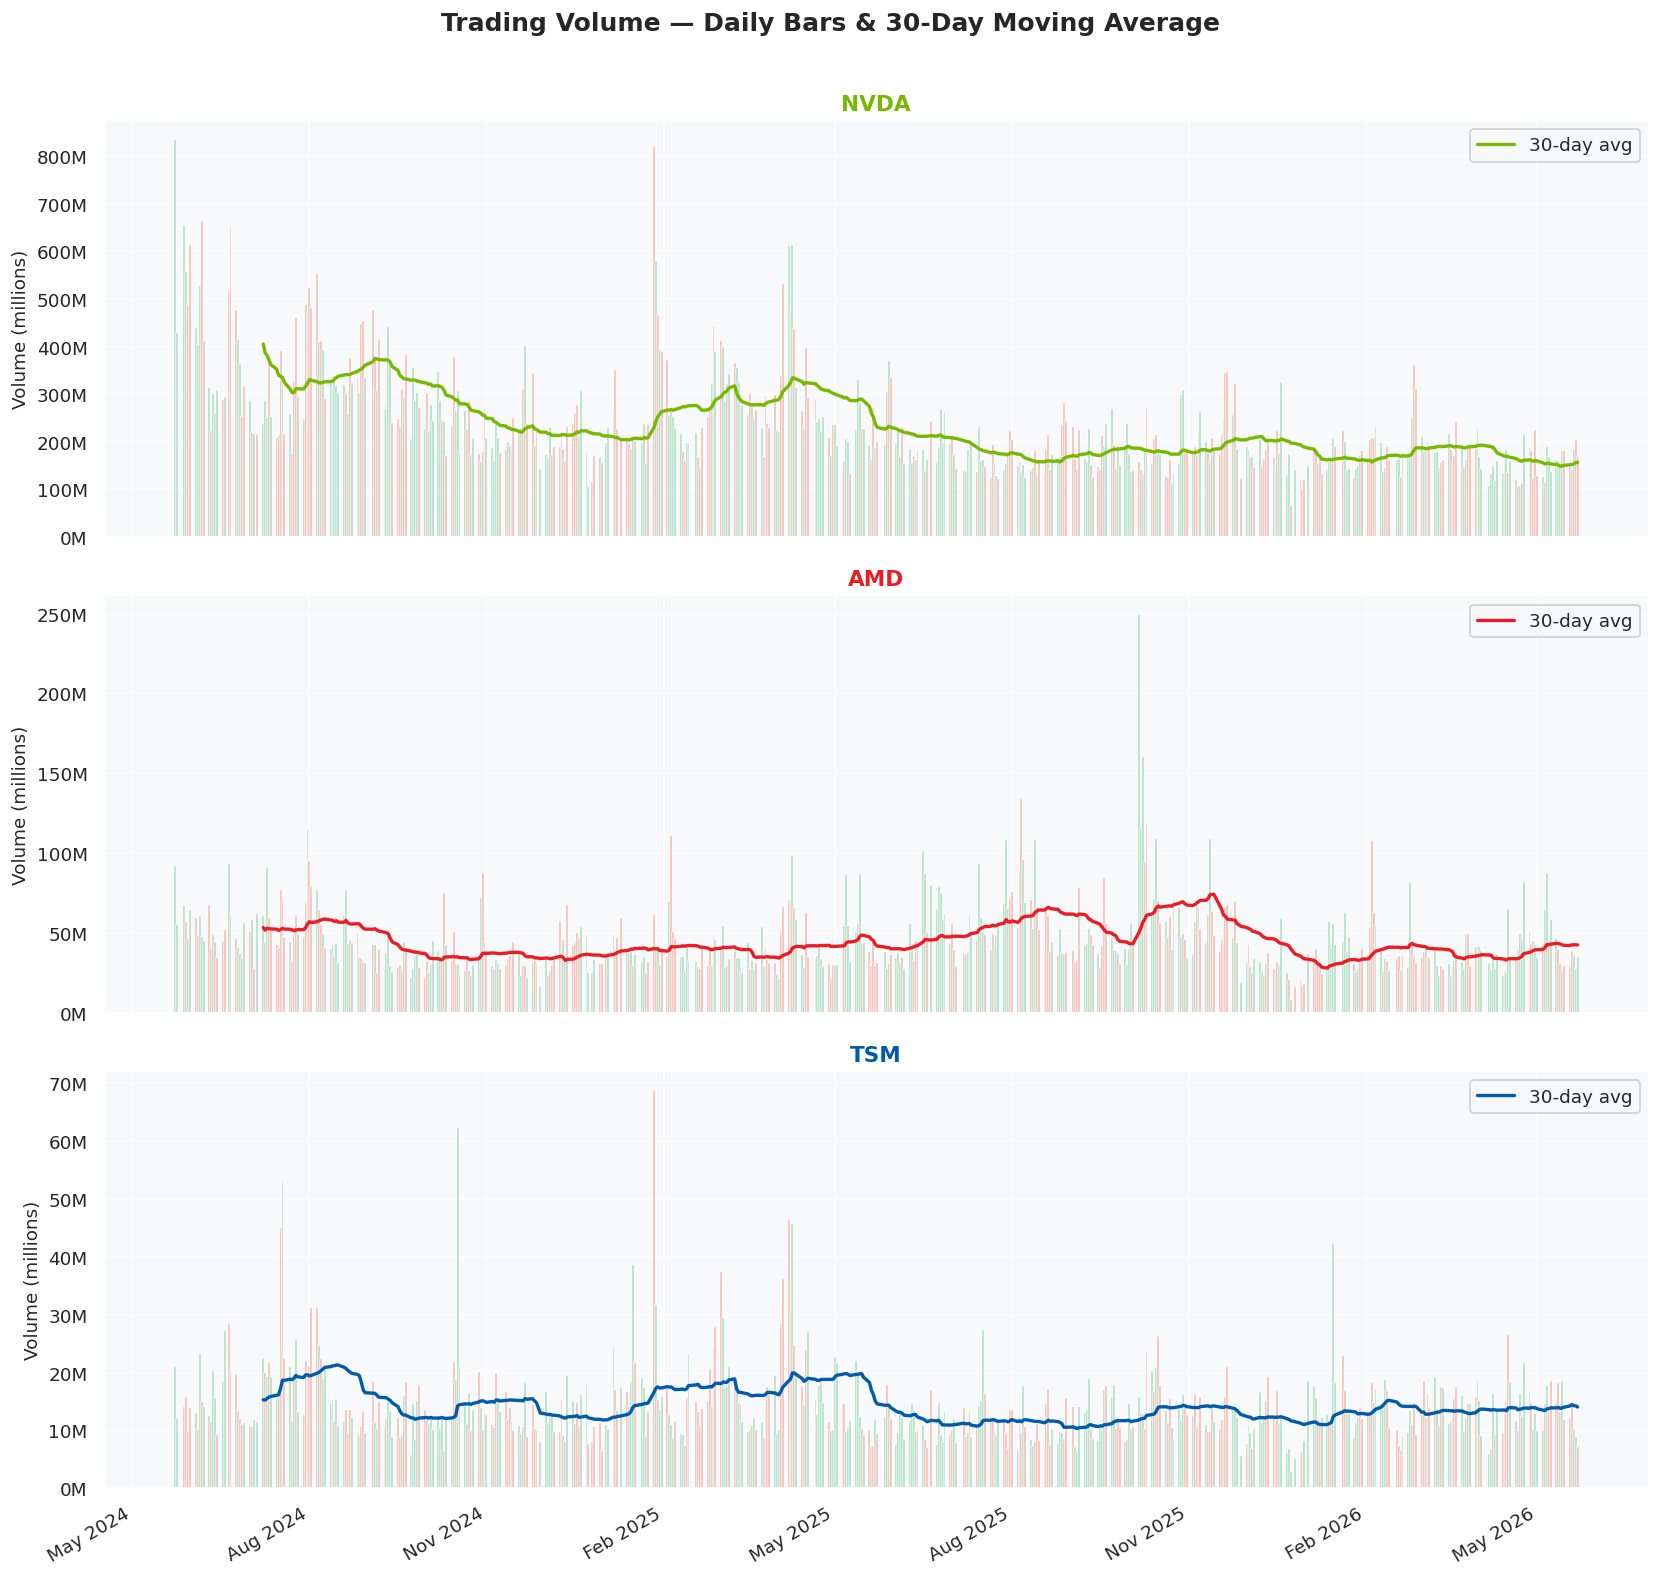

Saved → charts/09_volume_analysis.png


In [13]:
roll_vol_30 = volume.rolling(30).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)
fig.suptitle('Trading Volume — Daily Bars & 30-Day Moving Average',
             fontsize=15, fontweight='bold', y=1.01)

for ax, ticker in zip(axes, TICKERS):
    color = COLORS[ticker]

    # Colour bars by whether close went up or down
    daily_ret = close[ticker].pct_change()
    bar_colors = ['#27ae60' if r >= 0 else '#e74c3c' for r in daily_ret.fillna(0)]

    ax.bar(volume.index, volume[ticker] / 1e6, color=bar_colors, alpha=0.55, width=1)
    ax.plot(roll_vol_30.index, roll_vol_30[ticker] / 1e6,
            color=color, linewidth=2, label='30-day avg')

    ax.set_title(ticker, fontsize=13, color=color, fontweight='bold')
    ax.set_ylabel('Volume (millions)', fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=11, framealpha=0.9)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '09_volume_analysis.png', bbox_inches='tight')
plt.show()
print('Saved → charts/09_volume_analysis.png')

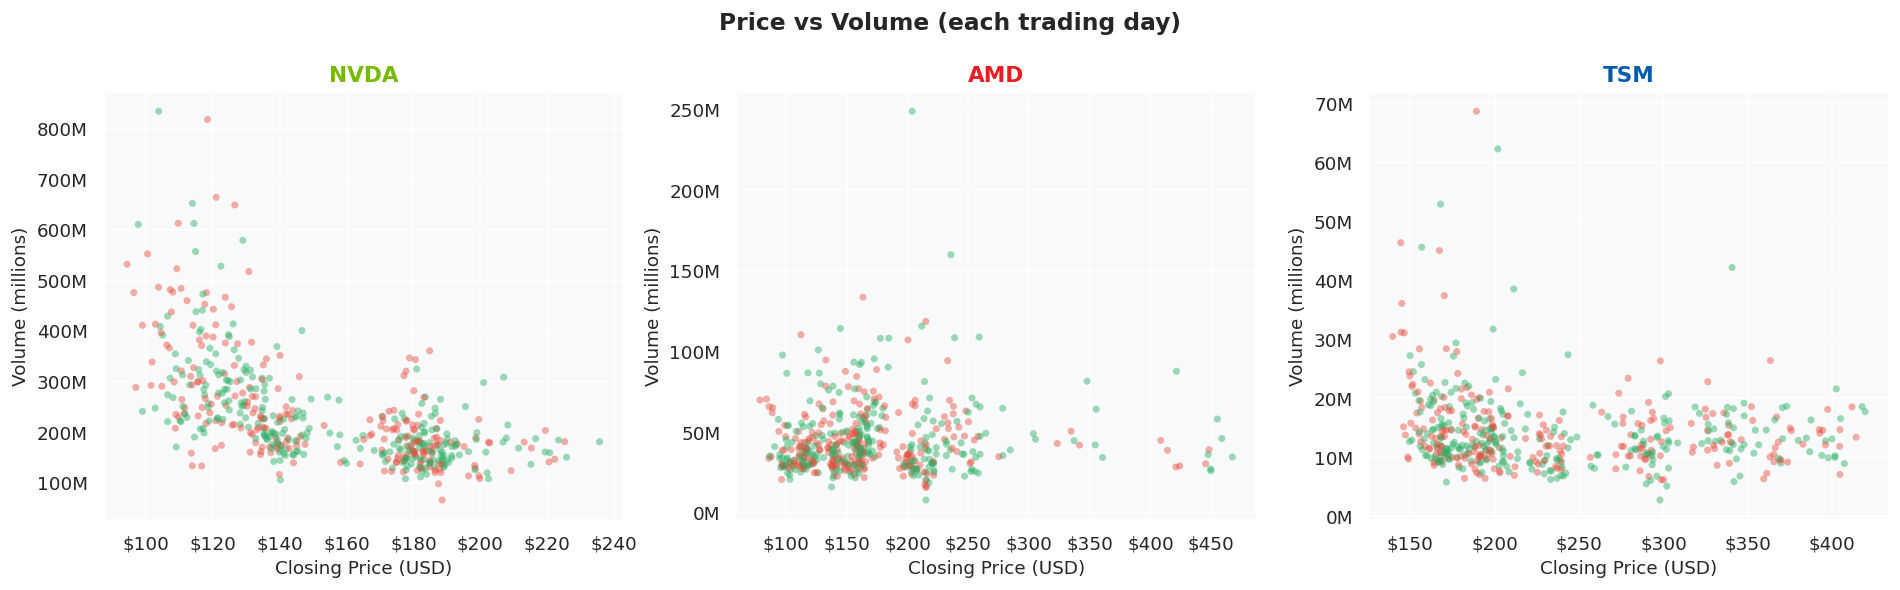

Saved → charts/10_price_vs_volume.png


In [14]:
# Price × Volume scatter — large volume days stand out
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Price vs Volume (each trading day)', fontsize=14, fontweight='bold')

for ax, ticker in zip(axes, TICKERS):
    color = COLORS[ticker]
    ret = daily_returns[ticker].reindex(volume.index)
    scatter_colors = ['#27ae60' if r >= 0 else '#e74c3c' for r in ret.fillna(0)]
    ax.scatter(close[ticker], volume[ticker] / 1e6,
               c=scatter_colors, alpha=0.45, s=18, edgecolors='none')
    ax.set_title(ticker, fontsize=13, color=color, fontweight='bold')
    ax.set_xlabel('Closing Price (USD)', fontsize=11)
    ax.set_ylabel('Volume (millions)', fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))

plt.tight_layout()
fig.savefig(CHARTS_DIR / '10_price_vs_volume.png', bbox_inches='tight')
plt.show()
print('Saved → charts/10_price_vs_volume.png')

## Section 8 — Summary Statistics

Consolidated snapshot of key risk/return metrics across all three stocks.

In [15]:
trading_days = len(daily_returns)

rows = []
for ticker in TICKERS:
    ann_ret  = ((1 + daily_returns[ticker].mean()) ** 252 - 1) * 100
    ann_vol  = daily_returns[ticker].std() * np.sqrt(252) * 100
    sharpe   = ann_ret / ann_vol
    max_dd   = (close[ticker] / close[ticker].cummax() - 1).min() * 100
    total_r  = ((close[ticker].iloc[-1] / close[ticker].iloc[0]) - 1) * 100

    rows.append({
        'Ticker':           ticker,
        'Start Price':      f'${close[ticker].iloc[0]:.2f}',
        'End Price':        f'${close[ticker].iloc[-1]:.2f}',
        'Total Return':     f'{total_r:+.1f}%',
        'Ann. Return':      f'{ann_ret:+.1f}%',
        'Ann. Volatility':  f'{ann_vol:.1f}%',
        'Sharpe Ratio':     f'{sharpe:.2f}',
        'Max Drawdown':     f'{max_dd:.1f}%',
    })

summary_df = pd.DataFrame(rows).set_index('Ticker')
print('=== SUMMARY TABLE ===')
print(summary_df.to_string())

=== SUMMARY TABLE ===
       Start Price End Price Total Return Ann. Return Ann. Volatility Sharpe Ratio Max Drawdown
Ticker                                                                                         
NVDA       $103.74   $215.33      +107.6%      +62.3%           48.3%         1.29       -36.9%
AMD        $160.43   $467.51      +191.4%     +103.5%           59.4%         1.74       -57.5%
TSM        $153.03   $404.52      +164.3%      +77.7%           41.4%         1.88       -36.8%


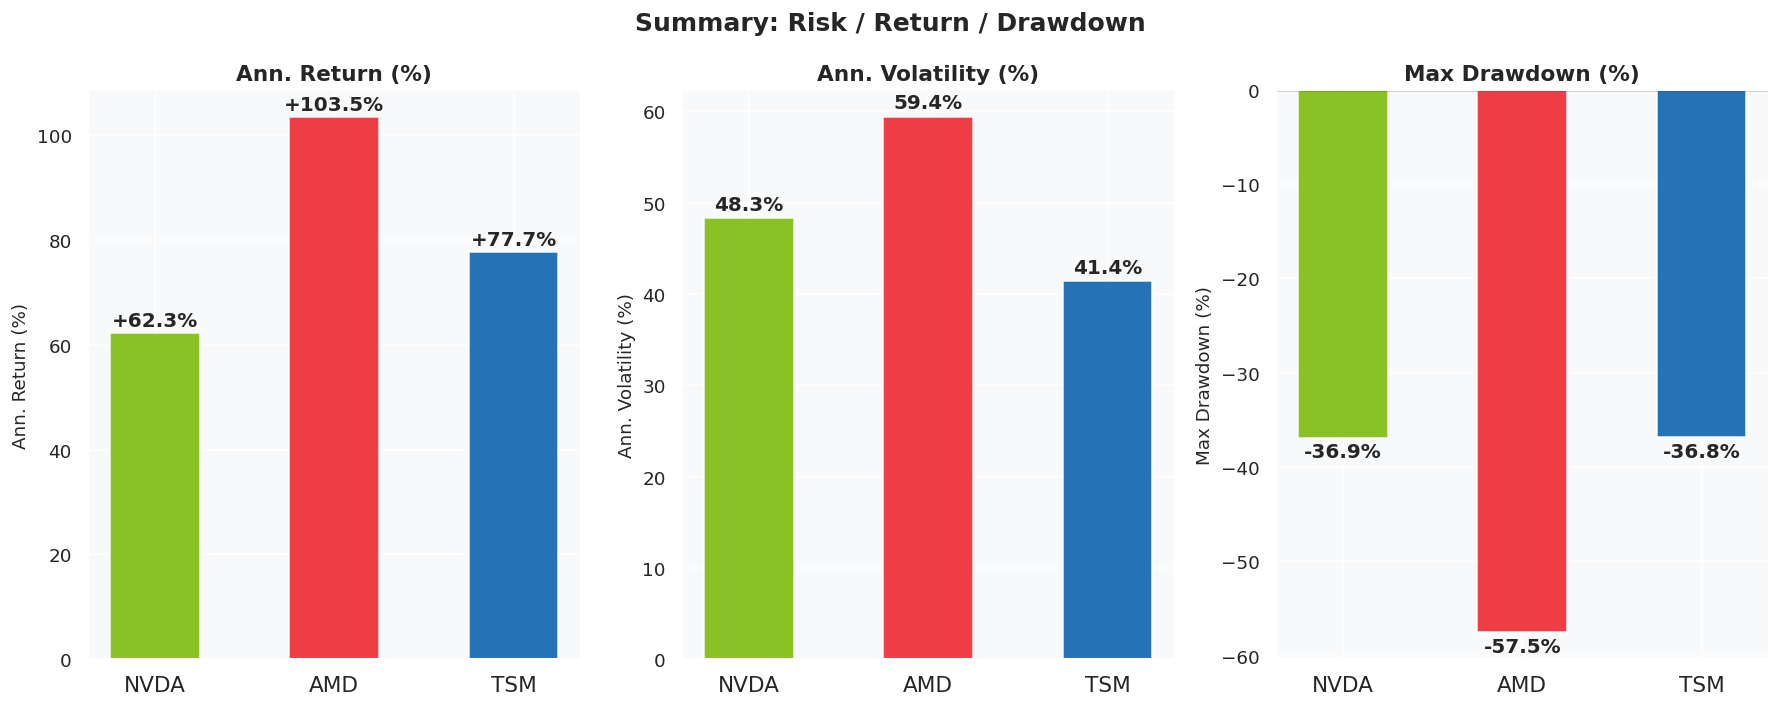

Saved → charts/11_summary_metrics.png


In [16]:
# Summary bar charts — Ann. Return vs Ann. Volatility
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Summary: Risk / Return / Drawdown', fontsize=15, fontweight='bold')

metrics = {
    'Ann. Return (%)':    [(((1 + daily_returns[t].mean()) ** 252 - 1) * 100) for t in TICKERS],
    'Ann. Volatility (%)':[(daily_returns[t].std() * np.sqrt(252) * 100) for t in TICKERS],
    'Max Drawdown (%)':   [((close[t] / close[t].cummax() - 1).min() * 100) for t in TICKERS],
}

for ax, (title, vals) in zip(axes, metrics.items()):
    bar_colors = [COLORS[t] for t in TICKERS]
    bars = ax.bar(TICKERS, vals, color=bar_colors, width=0.5, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.5 if val >= 0 else -2.5),
                f'{val:+.1f}%' if 'Return' in title or 'Drawdown' in title else f'{val:.1f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel(title, fontsize=11)
    ax.tick_params(axis='x', labelsize=13)

plt.tight_layout()
fig.savefig(CHARTS_DIR / '11_summary_metrics.png', bbox_inches='tight')
plt.show()
print('Saved → charts/11_summary_metrics.png')

In [17]:
# Print chart inventory
print('\n=== Generated Charts ===')
for p in sorted(CHARTS_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<40} {size_kb:>6.1f} KB')

print(f'\nAnalysis complete — {TODAY}')


=== Generated Charts ===
  01_price_history.png                      172.3 KB
  02_normalised_price.png                   154.1 KB
  03_cumulative_returns.png                 162.4 KB
  04_return_distributions.png                80.6 KB
  05_volatility.png                         205.3 KB
  06_moving_averages.png                    297.4 KB
  07_correlation_heatmap.png                 66.1 KB
  08_returns_pairplot.png                   111.5 KB
  09_volume_analysis.png                    173.1 KB
  10_price_vs_volume.png                    177.2 KB
  11_summary_metrics.png                     62.5 KB

Analysis complete — 2026-05-24
